# Week 5 · Notebook 4 — ACO Theory and Extensions

**Goals**
- Read ACO as *model-based search*: a parametric distribution over solutions that is updated from its own samples,
  and show that a pheromone update is a natural-gradient step on expected quality (Meuleau & Dorigo 2002;
  Zlochin, Birattari, Meuleau & Dorigo 2004).
- Implement the cross-entropy (CE) method (Rubinstein 1997, 1999), verify its update is a maximum-likelihood fit, and
  show that it coincides with a hyper-cube ACO update; compare CE and ACO on 0/1 knapsack against the DP optimum.
- State the convergence results of Gutjahr (2000, 2002) and Stützle & Dorigo (2002) precisely and check their
  quantitative consequences on small TSPs.
- Measure stagnation through the entropy of the pheromone distribution and verify the MMAS limit entropy.
- Implement ACO$_\mathbb{R}$ (Socha & Dorigo 2008) for continuous domains and compare it with PSO at equal budgets.

**Prerequisites:** Notebook 3 (AS, ACS, MMAS), Notebook 1 (PSO), score-function gradients, maximum likelihood.

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np
import matplotlib.pyplot as plt
from utils import set_style, savefig, check_close, check_true
set_style()
rng = np.random.default_rng(0)
from itertools import product
from scipy.optimize import minimize
from scipy.stats import chisquare, mannwhitneyu
from utils import (random_knapsack, knapsack_dp, random_euclidean_tsp, tour_length, held_karp, BENCHMARKS, PALETTE)

## 1. ACO as model-based search and stochastic gradient ascent

**Model-based search** (Zlochin, Birattari, Meuleau & Dorigo 2004, *Model-based search for combinatorial
optimization: a critical survey*, Annals of OR 131:373–395) iterates: sample solutions from a parametric model
$P_\theta$; evaluate them; update $\theta$ so that good solutions become more likely. ACO's pheromones are $\theta$,
the construction rule defines $P_\theta$; the CE method and estimation-of-distribution algorithms are other
instances.

Take the goal $\max_\theta J(\theta)=\mathbb E_{s\sim P_\theta}[F(s)]$ for a quality $F\ge0$. The score-function
(likelihood-ratio / REINFORCE) identity

$$
\nabla_\theta J(\theta)=\mathbb E_{s\sim P_\theta}\bigl[F(s)\,\nabla_\theta\log P_\theta(s)\bigr]
\approx\frac1N\sum_{k=1}^N F(s_k)\nabla_\theta\log P_\theta(s_k)
$$

gives an unbiased stochastic gradient from the ants' own samples (Meuleau & Dorigo 2002, *Ant colony optimization
and stochastic gradient descent*, Artificial Life 8(2):103–121, derived AS-like updates this way).

**Worked case: independent binary decisions** ("pheromone on items"), $P_p(s)=\prod_i p_i^{s_i}(1-p_i)^{1-s_i}$.
Then $\partial_{p_i}\log P_p(s)=\frac{s_i-p_i}{p_i(1-p_i)}$ and the Fisher information is
$\mathcal I(p)=\mathrm{diag}\bigl(1/(p_i(1-p_i))\bigr)$. The *natural-gradient* step
$p\leftarrow p+\eta\,\mathcal I(p)^{-1}\hat\nabla J$ is

$$
p\leftarrow p+\frac{\eta}{N}\sum_k F(s_k)(s_k-p)=(1-\rho)\,p+\rho\sum_k\frac{F(s_k)}{\sum_lF(s_l)}\,s_k,
\qquad \rho=\frac{\eta}{N}\sum_kF(s_k),
$$

i.e. **evaporation + quality-weighted deposit**, exactly the update of the *hyper-cube framework* for ACO
(Blum & Dorigo 2004, IEEE Trans. SMC-B 34(2):1161–1172). Pheromone updates are natural-gradient ascent on expected
quality, with the evaporation rate playing the role of the learning rate.

**Validation.** For $n=10$ decisions (1024 solutions) and a random quality table we compute $J(p)$ *exactly* by
enumeration, differentiate it by central finite differences, and compare with the Monte Carlo score-function
estimate from $4\times10^5$ samples (tolerance: 4 standard errors per coordinate). Then we check that the natural
gradient step and the pheromone formula give the same new model.

In [2]:
n_b = 10
S_all = np.array(list(product([0, 1], repeat=n_b)), dtype=float)          # all 1024 solutions
F_tab = np.random.default_rng(1).gamma(2.0, 1.0, len(S_all)) * (1 + S_all @ np.linspace(0.2, 1, n_b))
F_of = lambda S: F_tab[(S.astype(int) * (1 << np.arange(n_b)[::-1])).sum(-1)]
check_true(np.array_equal(F_of(S_all), F_tab), "solution indexing is consistent")

def J_exact(p):
    P = np.prod(np.where(S_all == 1, p, 1 - p), axis=1)
    return P @ F_tab

p0 = np.random.default_rng(2).uniform(0.2, 0.8, n_b)
h = 1e-6
grad_fd = np.array([(J_exact(p0 + h * e) - J_exact(p0 - h * e)) / (2 * h) for e in np.eye(n_b)])
N = 400_000
S = (np.random.default_rng(3).random((N, n_b)) < p0).astype(float)
terms = F_of(S)[:, None] * (S - p0) / (p0 * (1 - p0))
grad_mc, se = terms.mean(0), terms.std(0) / np.sqrt(N)
z = np.abs(grad_mc - grad_fd) / se
print("finite-difference gradient:", np.round(grad_fd, 3))
print("score-function estimate:   ", np.round(grad_mc, 3), f"  max |z| = {z.max():.2f}")
check_true(z.max() < 4, "score-function gradient agrees with the exact (enumeration + finite difference) gradient")

eta = 0.02
S_small, F_small = S[:50], F_of(S[:50])
g_hat = (F_small[:, None] * (S_small - p0) / (p0 * (1 - p0))).mean(0)
p_natgrad = p0 + eta * (p0 * (1 - p0)) * g_hat                            # Fisher^{-1} times gradient
rho_eq = eta * F_small.sum() / len(F_small)
p_pher = (1 - rho_eq) * p0 + rho_eq * (F_small / F_small.sum()) @ S_small  # evaporation + weighted deposit
check_close(np.abs(p_natgrad - p_pher).max(), 0.0, "max |natural-gradient step - hyper-cube pheromone update|", atol=1e-12)

[PASS] solution indexing is consistent


finite-difference gradient: [0.626 0.922 0.571 1.266 0.845 1.078 2.117 1.391 1.579 0.821]
score-function estimate:    [0.535 0.882 0.606 1.24  0.831 1.031 2.137 1.386 1.642 0.789]   max |z| = 3.06
[PASS] score-function gradient agrees with the exact (enumeration + finite difference) gradient
[PASS] max |natural-gradient step - hyper-cube pheromone update|: got 0.0, expected 0.0


## 2. The cross-entropy method and its relation to pheromone updates

Rubinstein introduced CE for rare-event estimation (1997, EJOR 99:89–112) and for combinatorial optimisation
(1999, Methodology and Computing in Applied Probability 1:127–190); see the tutorial by de Boer, Kroese, Mannor &
Rubinstein (2005, Annals of OR 134:19–67). One iteration:

```text
sample N solutions from P_p; let gamma = the (1 - rho_e) quantile of their qualities (elite threshold)
p_hat = argmax_p  sum over elite samples of log P_p(s)          # maximum-likelihood fit to the elite
p     = (1 - a) p + a p_hat                                     # smoothing
```

The ML step minimises the cross-entropy (KL divergence) between the elite empirical distribution and $P_p$. For the
Bernoulli model it has the closed form $\hat p_i=$ mean of $s_i$ over the elite. The smoothed CE update is therefore
$p\leftarrow(1-a)p+a\cdot\frac1{|E|}\sum_{s\in E}s$: **evaporation with rate $a$ and uniform deposit by the elite
ants** — the same update family as MMAS (elite = iteration-best ant) and the hyper-cube framework
(Zlochin et al. 2004 discuss this correspondence).

**Validation.** We maximise the elite log-likelihood numerically with `scipy.optimize` (L-BFGS-B) and compare with
the closed form.

In [3]:
elite = (np.random.default_rng(4).random((25, 12)) < np.random.default_rng(5).uniform(0.05, 0.95, 12)).astype(float)
nll = lambda p: -(elite * np.log(p) + (1 - elite) * np.log(1 - p)).sum()
sol = minimize(nll, np.full(12, 0.5), method="L-BFGS-B", bounds=[(1e-9, 1 - 1e-9)] * 12,
               jac=lambda p: -(elite / p - (1 - elite) / (1 - p)).sum(0), options=dict(ftol=1e-15, gtol=1e-12))
print("elite mean:", elite.mean(0)); print("L-BFGS-B:  ", np.round(sol.x, 6))
check_close(np.abs(sol.x - elite.mean(0)).max(), 0.0, "max |numerical ML fit - elite mean (CE closed form)|", atol=1e-5)

elite mean: [0.68 0.64 0.36 0.24 0.16 0.28 0.48 0.08 0.16 0.92 0.52 0.24]
L-BFGS-B:   [0.68 0.64 0.36 0.24 0.16 0.28 0.48 0.08 0.16 0.92 0.52 0.24]
[PASS] max |numerical ML fit - elite mean (CE closed form)|: got 0.0, expected 0.0


## 3. CE versus ACO on 0/1 knapsack (exact optimum by DP)

Instance: 60 items, *strongly correlated* ($v_i=w_i+10$, the hard Pisinger class), capacity half the total weight;
`knapsack_dp` gives the exact optimum. Both methods get **6000 evaluations**, 12 independent runs.

* **CE**: independent Bernoulli model, $N=100$ samples per iteration, elite fraction 10%, smoothing $a=0.7$;
  infeasible samples are repaired by removing items in increasing order of $v_i/w_i$ (no heuristic otherwise).
* **ACO (MMAS-style, hyper-cube bounds)**: pheromone $\tau_i\in[1/n,1]$ on items, heuristic $\eta_i=v_i/w_i$;
  an ant adds items one at a time with probability $\propto\tau_i^{\alpha}\eta_i^{\beta}$ among the items that still fit
  (so every solution is feasible and maximal); update $\tau\leftarrow(1-\rho)\tau+\rho\,\mathbb 1[i\in s_{\text{ib}}]$,
  $\alpha=1$, $\beta=2$, $\rho=0.1$, $m=20$ ants. This is the CE update with a one-element elite — the difference
  between the two methods is the *sampling* (sequential, heuristic-guided, feasibility-aware construction).

In [4]:
v_k, w_k, C_k = random_knapsack(60, np.random.default_rng(6), correlation="strong")
opt_k, x_k = knapsack_dp(v_k, w_k, C_k)
check_true(w_k @ x_k <= C_k and abs(v_k @ x_k - opt_k) < 1e-9, f"DP solution is feasible and attains its value {opt_k:.0f}")
order_up = np.argsort(v_k / w_k)            # removal order for the repair (worst ratio first)
nk = len(v_k)

def repair(S):
    """Drop items in increasing v/w order until the capacity holds (vectorised over leading axes)."""
    Wo = (S * w_k)[..., order_up]
    excess = Wo.sum(-1) - C_k
    before = np.cumsum(Wo, -1) - Wo
    drop_o = (Wo > 0) & (before < excess[..., None])
    drop = np.zeros_like(S); drop[..., order_up] = drop_o
    return S & ~drop

S_test = np.random.default_rng(7).random((1000, nk)) < 0.7
R_test = repair(S_test)
check_true(np.all(R_test.astype(float) @ w_k <= C_k) and np.all(R_test <= S_test), "repair yields feasible subsets of the input")
S_low = np.random.default_rng(8).random((500, nk)) < 0.4
feas = S_low[(S_low.astype(float) @ w_k) <= C_k]
check_true(len(feas) > 50 and np.array_equal(repair(feas), feas), f"repair leaves {len(feas)} feasible solutions unchanged")


def sample_next(w, rng):
    cum = np.cumsum(w, axis=-1)
    u = rng.random(w.shape[:-1]) * cum[..., -1]
    return (cum <= u[..., None]).sum(-1)


def ce_knapsack(runs, budget, N=100, elite_frac=0.1, a=0.7, rng=None):
    p = np.full((runs, nk), 0.5)
    Ne, rr = int(elite_frac * N), np.arange(runs)[:, None]
    best, hist = np.zeros(runs), []
    for _ in range(budget // N):
        S = repair(rng.random((runs, N, nk)) < p[:, None, :])
        val = S.astype(float) @ v_k
        idx = np.argsort(-val, axis=1)[:, :Ne]
        p = (1 - a) * p + a * S[rr, idx].mean(1)
        best = np.maximum(best, val.max(1)); hist.append(best.copy())
    return best, np.array(hist).T, p


def aco_knapsack(runs, budget, m=20, alpha=1.0, beta=2.0, rho=0.1, rng=None):
    tau = np.ones((runs, nk)); tmin = 1.0 / nk
    eta = (v_k / w_k) / (v_k / w_k).max()
    rr, mm = np.arange(runs)[:, None], np.arange(m)[None, :]
    best, hist = np.zeros(runs), []
    for _ in range(budget // m):
        Wt = (tau**alpha * eta**beta)[:, None, :]
        chosen = np.zeros((runs, m, nk), bool); rem = np.full((runs, m), C_k)
        while True:
            feas = ~chosen & (w_k <= rem[..., None])
            has = feas.any(-1)
            if not has.any():
                break
            wts = np.where(has[..., None], Wt * feas, 1.0)
            nxt = sample_next(wts, rng)
            chosen[rr, mm, nxt] |= has
            rem = rem - w_k[nxt] * has
        val = chosen.astype(float) @ v_k
        ib = val.argmax(1)
        tau = np.clip((1 - rho) * tau + rho * chosen[rr[:, 0], ib], tmin, 1.0)
        best = np.maximum(best, val.max(1)); hist.append(best.copy())
    return best, np.array(hist).T, tau

KB = 6000
ce_best, ce_hist, ce_p = ce_knapsack(12, KB, rng=np.random.default_rng(9))
ac_best, ac_hist, ac_tau = aco_knapsack(12, KB, rng=np.random.default_rng(10))
greedy = repair(np.ones((1, nk), bool))[0].astype(float) @ v_k
print(f"DP optimum {opt_k:.0f};  greedy-by-ratio (repair of the full set) {greedy:.0f}")
for name, b in [("CE", ce_best), ("ACO", ac_best)]:
    gap = 100 * (1 - b / opt_k)
    print(f"  {name:4s} gap median {np.median(gap):.3f}%  IQR [{np.percentile(gap, 25):.3f}, {np.percentile(gap, 75):.3f}]"
          f"  optimum hit {np.mean(b >= opt_k - 1e-9):.0%}")
print(f"Mann-Whitney CE vs ACO p = {mannwhitneyu(ce_best, ac_best).pvalue:.1e}")
check_true(max(ce_best.max(), ac_best.max()) <= opt_k + 1e-9, "no method exceeds the DP optimum")
print(f"final CE model: {np.mean((ce_p < 0.01) | (ce_p > 0.99)):.0%} of the item probabilities are within 0.01 of 0 or 1")

[PASS] DP solution is feasible and attains its value 2003
[PASS] repair yields feasible subsets of the input
[PASS] repair leaves 459 feasible solutions unchanged


DP optimum 2003;  greedy-by-ratio (repair of the full set) 1973
  CE   gap median 0.000%  IQR [0.000, 0.050]  optimum hit 67%
  ACO  gap median 0.000%  IQR [0.000, 0.000]  optimum hit 100%
Mann-Whitney CE vs ACO p = 3.7e-02
[PASS] no method exceeds the DP optimum
final CE model: 100% of the item probabilities are within 0.01 of 0 or 1


CE's model has collapsed to (nearly) a single solution by the end of the run (every item probability within 0.01 of
0 or 1) — the smoothing $a=0.7$ with a 10% elite is an aggressive learning rate — while the bounded ACO model keeps sampling around its best solutions.
ACO also benefits from its heuristic and from feasibility-aware construction. The same trade-off (learning rate vs
premature convergence) reappears below as pheromone entropy.

## 4. Convergence results, stated precisely

Let $s^{\ast}$ be an optimal solution and $P^{\ast}(t)$ the probability that it has been generated at least once in the
first $t$ iterations.

* **Gutjahr (2000)**, *A graph-based Ant System and its convergence*, FGCS 16(8):873–888, Theorem 4.1. For the
  graph-based Ant System (GBAS: $\alpha=1$, elitist reinforcement of the best walk found so far, a *unique* optimal
  walk $w^{\ast}$ with positive heuristic values along it), let $P_m$ be the probability that a *fixed* ant
  traverses $w^{\ast}$ in cycle $m$. For every $\varepsilon>0$: with $\rho$ and $\beta$ fixed, a sufficiently large
  number of ants gives $P_m\ge1-\varepsilon$ for all $m\ge m_0$; alternatively, with the number of ants fixed, an
  evaporation factor $\rho$ sufficiently close to $0$ gives the same conclusion. **Gutjahr (2002)**, *ACO algorithms
  with guaranteed convergence to the optimal solution*, IPL 82(3):145–153, obtained $P_m\to1$ (convergence in
  solution with probability one) for GBAS variants with a slowly decreasing evaporation rate or a slowly decreasing
  lower pheromone bound.
* **Stützle & Dorigo (2002)**, *A short convergence proof for a class of ACO algorithms*, IEEE TEC 6(4):358–365. For
  $\text{ACO}_{bs,\tau_{\min}}$ (best-so-far deposit, pheromones bounded below by a constant $\tau_{\min}>0$; the
  upper bound $\tau_{\max}=g(s^{\ast})/\rho$ then holds asymptotically by itself, their Proposition 1, and our
  implementation clips at it as MMAS does): every construction step has probability at least
  $p_{\min}\ge\frac{\tau_{\min}^\alpha\eta_{\min}^\beta}{(N_C-1)\tau_{\max}^\alpha\eta_{\max}^\beta+\tau_{\min}^\alpha\eta_{\min}^\beta}>0$,
  so any given solution is built in an iteration with probability $\hat p\ge p_{\min}^{\,n}$ and
  $P^{\ast}(t)\ge1-(1-\hat p)^{t}\to1$ (**convergence in value**). Moreover, once $s^{\ast}$ is found, the pheromone
  of every edge *not* in $s^{\ast}$ receives no deposit, so it equals $\tau_{\min}$ after at most
  $t_{\text{hit}}=\bigl\lceil\ln(\tau_{\min}/\tau_{\max})/\ln(1-\rho)\bigr\rceil$ further iterations, and the edges of $s^{\ast}$
  approach $\tau_{\max}$ geometrically — from then on $s^{\ast}$ is the most likely tour.

These are *asymptotic* guarantees: the bound $\hat p$ is astronomically small, so they say nothing useful about
runtime (as for SA's logarithmic cooling, Week 2). What they do say is structural: **without a positive lower bound
on the sampling probabilities there is no guarantee at all**, because pheromones can decay so far that the optimum
becomes practically unreachable.

We check the quantitative statements on a 10-city TSP with Held–Karp optimum: (i) empirical $P^{\ast}(t)$ over
100 runs versus the bound, with $\tau_{\min}>0$ and with $\tau_{\min}=0$ (the bound is so small that respecting it
is a sanity check only); (ii) after the last improvement, all non-best-tour edges are exactly at $\tau_{\min}$ no
later than $t_{\text{hit}}$ iterations; (iii) the informative part — the $\tau_{\min}=0$ runs that missed the
optimum are *locked in*: we bound, from their final pheromone matrix, the probability that an ant builds any tour
other than their best one. If the ant has followed the best tour so far, its next tour neighbour is still unvisited,
so by a union bound over the $n$ decisions

$$
P(\text{deviate})\le\sum_i\frac{\sum_{j\notin N^{\ast}(i)}\tau_{ij}^{\alpha}\eta_{ij}^{\beta}}{\min_{j\in N^{\ast}(i)}\tau_{ij}^{\alpha}\eta_{ij}^{\beta}},
$$

where $N^{\ast}(i)$ are the two neighbours of $i$ in the best tour. With $\tau_{\min}>0$ the same bound is large,
i.e. those colonies keep exploring.

In [5]:
def construct_tours(W, m, rng, q0=0.0, local=None):
    """m tours per run from weights W (runs, n, n); local = (tau, eta_b, alpha, xi, tau0) enables ACS local update."""
    R, n, _ = W.shape
    tours = np.empty((R, m, n), dtype=int)
    cur = rng.integers(0, n, (R, m)); tours[:, :, 0] = cur
    unvisited = np.ones((R, m, n), bool)
    rr, mm = np.arange(R)[:, None], np.arange(m)[None, :]
    unvisited[rr, mm, cur] = False
    for s in range(1, n):
        w = W[rr, cur] * unvisited
        dead = w.sum(-1) <= 0
        if dead.any():
            w[dead] = unvisited[dead]
        nxt = sample_next(w, rng)
        if q0 > 0:
            nxt = np.where(rng.random((R, m)) < q0, w.argmax(-1), nxt)
        if local is not None:
            tau, eta_b, alpha, xi, tau0 = local
            new = (1 - xi) * tau[rr, cur, nxt] + xi * tau0
            tau[rr, cur, nxt] = new; tau[rr, nxt, cur] = new
            W[rr, cur, nxt] = new**alpha * eta_b[cur, nxt]; W[rr, nxt, cur] = W[rr, cur, nxt]
        tours[:, :, s] = nxt; unvisited[rr, mm, nxt] = False; cur = nxt
    return tours


def deposit(tau, tours, amount):
    R = tours.shape[0]
    a, b = tours, np.roll(tours, -1, axis=-1)
    rix = np.broadcast_to(np.arange(R)[:, None, None], a.shape)
    amt = np.broadcast_to(amount[..., None], a.shape)
    np.add.at(tau, (rix, a, b), amt); np.add.at(tau, (rix, b, a), amt)


def row_entropy(tau):
    """Mean over cities of the entropy of the normalised pheromone row (diagonal excluded). tau: (R, n, n)."""
    n = tau.shape[-1]
    off = ~np.eye(n, dtype=bool)
    T = tau[:, off].reshape(tau.shape[0], n, n - 1)
    P = T / T.sum(-1, keepdims=True)
    return -(P * np.log(np.where(P > 0, P, 1.0))).sum(-1).mean(-1)


def aco_tsp(D, variant="MMAS", runs=1, iters=100, m=None, alpha=1.0, beta=2.0, rho=None, q0=0.9, xi=0.1,
            p_best=0.05, use_tau_min=True, rng=None):
    """AS / ACS / MMAS (iteration-best) / BS (= ACO_bs,tau_min: best-so-far deposit) for the symmetric TSP.
    Vectorised over runs; records best-so-far, mean pheromone row entropy and the last-improvement iteration."""
    n = len(D)
    m = (10 if variant == "ACS" else n) if m is None else m
    rho = {"AS": 0.5, "ACS": 0.1, "MMAS": 0.1, "BS": 0.1}[variant] if rho is None else rho
    eta = 1.0 / (D + np.eye(n)); np.fill_diagonal(eta, 0.0); eta_b = eta**beta
    t_nn, left = [0], set(range(1, n))
    while left:
        j = min(left, key=lambda c: D[t_nn[-1], c]); t_nn.append(j); left.remove(j)
    Cnn = tour_length(t_nn, D)
    tau0 = {"AS": m / Cnn, "ACS": 1 / (n * Cnn)}.get(variant, 1 / (rho * Cnn))
    tau = np.full((runs, n, n), tau0)
    rr = np.arange(runs)
    best_len, best_tour = np.full(runs, np.inf), np.zeros((runs, n), int)
    last_imp = np.zeros(runs, int)
    hist, ent = [], []
    pdec = p_best ** (1.0 / n)
    for it in range(iters):
        W = tau**alpha * eta_b
        tours = construct_tours(W, m, rng, q0=q0 if variant == "ACS" else 0.0,
                                local=(tau, eta_b, alpha, xi, tau0) if variant == "ACS" else None)
        L = D[tours, np.roll(tours, -1, axis=-1)].sum(-1)
        ib = L.argmin(1); L_ib, T_ib = L[rr, ib], tours[rr, ib]
        imp = L_ib < best_len - 1e-12
        best_len[imp], best_tour[imp], last_imp[imp] = L_ib[imp], T_ib[imp], it
        if variant == "AS":
            tau *= 1 - rho; deposit(tau, tours, 1.0 / L)
        elif variant == "ACS":
            a, b = best_tour, np.roll(best_tour, -1, axis=1); ri = np.broadcast_to(rr[:, None], a.shape)
            new = (1 - rho) * tau[ri, a, b] + rho / best_len[:, None]; tau[ri, a, b] = new; tau[ri, b, a] = new
        else:
            tau *= 1 - rho
            dep_t, dep_L = (T_ib, L_ib) if variant == "MMAS" else (best_tour, best_len)
            deposit(tau, dep_t[:, None, :], 1.0 / dep_L[:, None])
            tmax = 1.0 / (rho * best_len)
            tmin = tmax * (1 - pdec) / ((n / 2 - 1) * pdec) if use_tau_min else np.zeros(runs)
            tau = np.clip(tau, tmin[:, None, None], tmax[:, None, None])
        hist.append(best_len.copy()); ent.append(row_entropy(tau))
    return dict(best_len=best_len, best_tour=best_tour, hist=np.array(hist).T, ent=np.array(ent).T,
                last_imp=last_imp, tau=tau, rho=rho)

ACO_bs, tau_min > 0: runs that found the optimum within 300 iterations: 100%


ACO_bs, tau_min = 0: runs that found the optimum within 300 iterations: 53%
p_min = 4.69e-05, per-iteration bound p_hat = 2.19e-39; bound after 300 iterations: 6.58e-37
[PASS] empirical P*(t) respects the positive Stuetzle-Dorigo lower bound at every t
t_hit = 7 iterations; 100 of 100 runs had their last improvement at least t_hit iterations before the end
[PASS] in all those runs every edge outside the best tour sits exactly at tau_min
tau_min = 0: 47 runs missed s*; largest deviation bound among them 3.8e-43 (best-so-far lengths [0.0031 0.0084 0.0134 0.0598 0.063  0.1013 0.1112 0.1143 0.2016] above the optimum, relative)
tau_min > 0: smallest deviation bound over the 100 runs 3.17 (vacuous: the colony keeps exploring)
[PASS] every tau_min = 0 run that missed s* is locked in: P(any other tour) < 1e-6 per ant


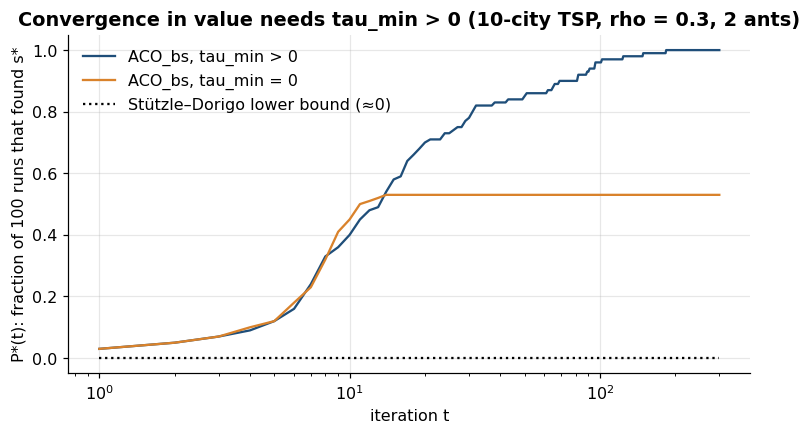

In [6]:
_, D10 = random_euclidean_tsp(10, np.random.default_rng(21))
opt10, opt_tour10 = held_karp(D10)
IT = 300
conv = {}
for k, (label, kw) in enumerate([("ACO_bs, tau_min > 0", dict(use_tau_min=True)),
                                 ("ACO_bs, tau_min = 0", dict(use_tau_min=False))]):
    conv[label] = aco_tsp(D10, "BS", runs=100, iters=IT, m=2, rho=0.3, rng=np.random.default_rng(22 + k), **kw)
    found = conv[label]["hist"] <= opt10 + 1e-9
    print(f"{label}: runs that found the optimum within {IT} iterations: {found[:, -1].mean():.0%}")

# the Stuetzle-Dorigo lower bound for this instance (m = 2 ants per iteration, alpha = 1, beta = 2)
n10, rho10 = 10, 0.3
eta10 = 1 / (D10 + np.eye(10)); off10 = ~np.eye(10, dtype=bool)
emin, emax = (eta10[off10] ** 2).min(), (eta10[off10] ** 2).max()
tmax_b = 1 / (rho10 * opt10)                                       # largest possible tau_max (L_bs >= optimum)
L_worst = D10[off10].max() * n10
tmin_b = (1 / (rho10 * L_worst)) * (1 - 0.05 ** (1 / n10)) / ((n10 / 2 - 1) * 0.05 ** (1 / n10))  # smallest tau_min
p_min = tmin_b * emin / ((n10 - 2) * tmax_b * emax + tmin_b * emin)
p_tour = p_min ** (n10 - 1)                                        # n-1 decisions per tour
p_hat = -np.expm1(2 * np.log1p(-p_tour))                            # two ants per iteration (computed stably)
P_emp = (conv["ACO_bs, tau_min > 0"]["hist"] <= opt10 + 1e-9).mean(0)
bound = -np.expm1(np.arange(1, IT + 1) * np.log1p(-p_hat))
print(f"p_min = {p_min:.2e}, per-iteration bound p_hat = {p_hat:.2e}; bound after {IT} iterations: {bound[-1]:.2e}")
check_true(p_hat > 0 and np.all(P_emp >= bound), "empirical P*(t) respects the positive Stuetzle-Dorigo lower bound at every t")

# (ii) after the last improvement every non-best edge reaches tau_min within t_hit iterations
r_bs = conv["ACO_bs, tau_min > 0"]
pd = 0.05 ** (1 / 10)
ok = []
for r in range(100):
    since = IT - 1 - r_bs["last_imp"][r]
    tmax_r = 1 / (rho10 * r_bs["best_len"][r]); tmin_r = tmax_r * (1 - pd) / ((10 / 2 - 1) * pd)
    t_hit = int(np.ceil(np.log(tmin_r / tmax_r) / np.log(1 - rho10)))
    if since >= t_hit:
        bt = r_bs["best_tour"][r]; on = np.zeros((10, 10), bool)
        on[bt, np.roll(bt, -1)] = True; on[np.roll(bt, -1), bt] = True
        ok.append(np.allclose(r_bs["tau"][r][off10 & ~on], tmin_r, rtol=1e-12))
print(f"t_hit = {t_hit} iterations; {len(ok)} of 100 runs had their last improvement at least t_hit iterations before the end")
check_true(len(ok) > 50 and all(ok), "in all those runs every edge outside the best tour sits exactly at tau_min")

# (iii) lock-in of the tau_min = 0 runs that missed the optimum: union bound on the deviation probability
def deviation_bound(tau, tour, alpha=1.0, beta=2.0):
    """Upper bound on P(an ant builds a tour different from `tour`) under pheromone tau (n, n)."""
    Wd = tau**alpha * eta10**beta
    nb = np.zeros((10, 10), bool); nb[tour, np.roll(tour, -1)] = True; nb[np.roll(tour, -1), tour] = True
    off = np.where(nb | np.eye(10, dtype=bool), 0.0, Wd).sum(1)
    on_min = np.where(nb, Wd, np.inf).min(1)
    return float((off / on_min).sum())

r0, r1 = conv["ACO_bs, tau_min = 0"], conv["ACO_bs, tau_min > 0"]
failed = np.where(r0["best_len"] > opt10 + 1e-9)[0]
dev0 = np.array([deviation_bound(r0["tau"][r], r0["best_tour"][r]) for r in failed])
dev1 = np.array([deviation_bound(r1["tau"][r], r1["best_tour"][r]) for r in range(100)])
print(f"tau_min = 0: {len(failed)} runs missed s*; largest deviation bound among them {dev0.max():.1e} "
      f"(best-so-far lengths {np.unique(np.round(r0['best_len'][failed] / opt10 - 1, 4))} above the optimum, relative)")
print(f"tau_min > 0: smallest deviation bound over the 100 runs {dev1.min():.2f} (vacuous: the colony keeps exploring)")
check_true(len(failed) > 0 and dev0.max() < 1e-6,
           "every tau_min = 0 run that missed s* is locked in: P(any other tour) < 1e-6 per ant")

fig, ax = plt.subplots(figsize=(8, 4))
for k, (label, r) in enumerate(conv.items()):
    ax.plot(np.arange(1, IT + 1), (r["hist"] <= opt10 + 1e-9).mean(0), label=label, color=list(PALETTE.values())[k])
ax.plot(np.arange(1, IT + 1), bound, "k:", label="Stützle–Dorigo lower bound (≈0)")
ax.set_xscale("log"); ax.set_xlabel("iteration t"); ax.set_ylabel("P*(t): fraction of 100 runs that found s*")
ax.set_title("Convergence in value needs tau_min > 0 (10-city TSP, rho = 0.3, 2 ants)"); ax.legend()
savefig("w5_aco_convergence_in_value.png"); plt.show()

With $\tau_{\min}=0$ a fraction of the runs lock into a sub-optimal tour forever: pheromone outside the best-so-far
tour decays geometrically, so after a few dozen iterations the colony re-samples the same tour. With
$\tau_{\min}>0$ the empirical $P^{\ast}(t)$ keeps rising — the theorem's mechanism at work, even though its bound is
numerically useless.

## 5. Stagnation measured by pheromone entropy

For city $i$ let $\pi_{ij}=\tau_{ij}/\sum_{l\ne i}\tau_{il}$ and $H_i=-\sum_{j\neq i}\pi_{ij}\log\pi_{ij}$; we
track $\bar H=\frac1n\sum_iH_i$ (maximum $\log(n-1)$ for uniform pheromone). A colony *stagnates* when $\bar H$ is
small: pheromone alone then fixes the tour. For MMAS with best-so-far deposit, once the best tour is fixed each
row holds exactly two entries at $\tau_{\max}$ (the two tour neighbours) and $n-3$ at $\tau_{\min}$, so

$$
\bar H_{\lim}=-2q_{\max}\log q_{\max}-(n-3)q_{\min}\log q_{\min},\qquad
q_{\max}=\frac{\tau_{\max}}{2\tau_{\max}+(n-3)\tau_{\min}},\ q_{\min}=\frac{\tau_{\min}}{2\tau_{\max}+(n-3)\tau_{\min}},
$$

which depends only on $n$ and $p_{\text{best}}$ (the ratio $\tau_{\min}/\tau_{\max}$), not on the instance. We run
AS, ACS, MMAS (iteration-best) and $\text{ACO}_{bs,\tau_{\min}}$ on 30 cities (8 runs, 400 iterations) and verify the
limit on the converged $\text{ACO}_{bs,\tau_{\min}}$ runs.

H_lim = 1.239500 (max possible log 29 = 3.3673); converged BS runs: 7 of 8
[PASS] at least half of the best-so-far runs have been stable for 200 iterations
[PASS] max |entropy of converged ACO_bs,tau_min - H_lim|: got 0.0, expected 0.0
complete stagnation (two equal edges per row, all others 0) would give log 2 = 0.693
  AS  : median entropy at t=10, 50, 399: 1.776, 1.427, 1.342;  best length median 4.5711
  ACS : median entropy at t=10, 50, 399: 3.090, 3.087, 3.086;  best length median 4.5927
  MMAS: median entropy at t=10, 50, 399: 3.336, 1.627, 1.240;  best length median 4.5927
  BS  : median entropy at t=10, 50, 399: 3.319, 1.438, 1.240;  best length median 4.5712


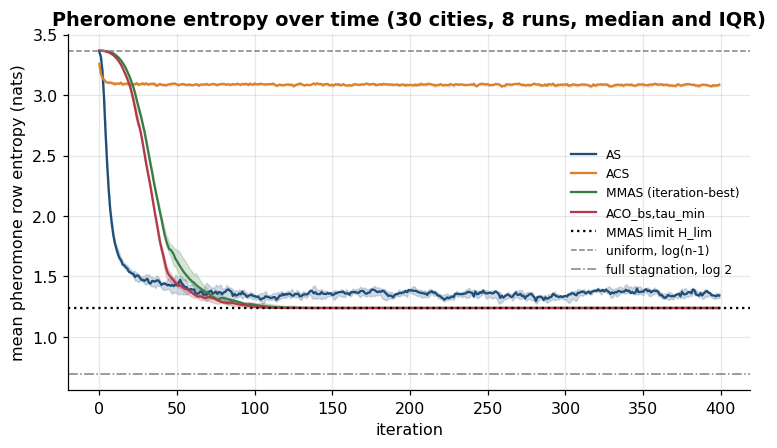

In [7]:
_, D30 = random_euclidean_tsp(30, np.random.default_rng(30))
ent_res = {v: aco_tsp(D30, v, runs=8, iters=400, m=10 if v == "ACS" else 30, rng=np.random.default_rng(31 + k))
           for k, v in enumerate(["AS", "ACS", "MMAS", "BS"])}
n30, pd30 = 30, 0.05 ** (1 / 30)
ratio = (1 - pd30) / ((n30 / 2 - 1) * pd30)
qmax, qmin = 1 / (2 + (n30 - 3) * ratio), ratio / (2 + (n30 - 3) * ratio)
H_lim = -2 * qmax * np.log(qmax) - (n30 - 3) * qmin * np.log(qmin)
r_bs = ent_res["BS"]
conv_runs = (400 - 1 - r_bs["last_imp"]) >= 200
print(f"H_lim = {H_lim:.6f} (max possible log 29 = {np.log(29):.4f}); converged BS runs: {conv_runs.sum()} of 8")
check_true(conv_runs.sum() >= 4, "at least half of the best-so-far runs have been stable for 200 iterations")
check_close(np.abs(r_bs["ent"][conv_runs, -1] - H_lim).max(), 0.0, "max |entropy of converged ACO_bs,tau_min - H_lim|", atol=1e-6)
print(f"complete stagnation (two equal edges per row, all others 0) would give log 2 = {np.log(2):.3f}")
for v, r in ent_res.items():
    print(f"  {v:4s}: median entropy at t=10, 50, 399: " + ", ".join(f"{np.median(r['ent'][:, t]):.3f}" for t in (10, 50, 399))
          + f";  best length median {np.median(r['best_len']):.4f}")

fig, ax = plt.subplots(figsize=(8, 4.2))
for k, (v, r) in enumerate(ent_res.items()):
    q1, m_, q3 = np.percentile(r["ent"], [25, 50, 75], axis=0)
    ax.plot(m_, label={"BS": "ACO_bs,tau_min", "MMAS": "MMAS (iteration-best)"}.get(v, v), color=list(PALETTE.values())[k])
    ax.fill_between(np.arange(400), q1, q3, alpha=0.2, color=list(PALETTE.values())[k])
ax.axhline(H_lim, color="k", ls=":", label="MMAS limit H_lim")
ax.axhline(np.log(29), color="grey", ls="--", lw=1, label="uniform, log(n-1)")
ax.axhline(np.log(2), color="grey", ls="-.", lw=1, label="full stagnation, log 2")
ax.set_xlabel("iteration"); ax.set_ylabel("mean pheromone row entropy (nats)")
ax.set_title("Pheromone entropy over time (30 cities, 8 runs, median and IQR)"); ax.legend(fontsize=8)
savefig("w5_aco_entropy.png"); plt.show()

The four variants use their pheromone very differently. **AS** concentrates earliest (its initial $\tau_0=m/C^{nn}$ is
quickly dominated by the deposits of all ants) and then plateaus: since every ant deposits, rows keep mass on several
edges. **MMAS** (iteration-best) and **$\text{ACO}_{bs,\tau_{\min}}$** start uniform at $\tau_{\max}$, descend
slowly and settle *exactly* at $\bar H_{\lim}$ — for MMAS the stagnation level is a design parameter
($p_{\text{best}}$), not an emergent property, and $\tau_{\min}$ keeps every edge sampleable. **ACS** keeps its
pheromone almost uniform: the local update pulls used edges back towards $\tau_0$ and only best-so-far edges are
reinforced, while exploitation comes from the greedy $q_0$ rule and from $\eta^\beta$. Pheromone entropy is
therefore a good stagnation measure for AS and MMAS, but for ACS the entropy of the full construction
distribution (including $q_0$ and $\eta$) would be needed. None of the variants reaches full stagnation
($\log2$, two edges per row).

## 6. ACO$_\mathbb{R}$: ant colony optimisation for continuous domains

**Socha & Dorigo (2008)**, *Ant colony optimization for continuous domains*, EJOR 185(3):1155–1173, replace the
pheromone table by a **solution archive** of $k$ solutions sorted by quality, $s_1$ best. The archive defines a
Gaussian mixture per coordinate. An ant
1. picks a guiding solution $l$ with probability $p_l=\omega_l/\sum_r\omega_r$,
   $\omega_l=\frac{1}{qk\sqrt{2\pi}}\exp\!\bigl(-\frac{(l-1)^2}{2q^2k^2}\bigr)$ (rank-based; small $q$ = greedy);
2. samples each coordinate $x^i\sim\mathcal N\bigl(s_l^i,\sigma_l^i\bigr)$ with
   $\sigma_l^i=\xi\sum_{e=1}^k\frac{|s_e^i-s_l^i|}{k-1}$ (the spread of the archive, scaled by $\xi$ — the analogue of
   evaporation: large $\xi$ = slow convergence);
3. the $m$ new solutions are added and the $m$ worst removed (the analogue of pheromone update).

In mechanism terms ACO$_\mathbb{R}$ is a $(k+m)$ rank-based estimation-of-distribution algorithm with an adaptive
(archive-spread) step size — close to an evolution strategy. We use the parameter values of Socha & Dorigo's benchmark
study, $k=50$, $m=2$, $\xi=0.85$, $q=10^{-4}$ (which makes $l=1$ essentially always), and also $q=0.1$ to show the
role of $q$. Samples are clipped to the box. Vectorised over runs.

In [8]:
def aco_r(f, d, lo, hi, budget, runs=1, k=50, m=2, q=1e-4, xi=0.85, rng=None):
    """ACO_R (Socha & Dorigo 2008), vectorised over independent runs. Returns best values and best-so-far trace."""
    A = rng.uniform(lo, hi, (runs, k, d))
    fA = f(A.reshape(-1, d)).reshape(runs, k)
    o = np.argsort(fA, 1); A, fA = np.take_along_axis(A, o[..., None], 1), np.take_along_axis(fA, o, 1)
    ranks = np.arange(k)
    w = np.exp(-ranks**2 / (2 * (q * k) ** 2)) / (q * k * np.sqrt(2 * np.pi))
    p = w / w.sum()
    cdf = np.cumsum(p); cdf[-1] = 1.0
    rr = np.arange(runs)[:, None]
    evals, grid, trace = k, [k], [fA[:, 0].copy()]
    while evals + m <= budget:
        l = np.searchsorted(cdf, rng.random((runs, m)), side="right")      # guide index with probability p_l
        G = A[rr, l]                                                        # (runs, m, d) guiding solutions
        At = np.ascontiguousarray(A.transpose(0, 2, 1))                     # (runs, d, k) for a fast reduction
        sigma = xi * np.abs(At[:, None] - G[..., None]).sum(-1) / (k - 1)
        X = np.clip(G + sigma * rng.standard_normal((runs, m, d)), lo, hi)
        fX = f(X.reshape(-1, d)).reshape(runs, m)
        evals += m
        A2, f2 = np.concatenate([A, X], 1), np.concatenate([fA, fX], 1)
        o = np.argsort(f2, 1, kind="stable")[:, :k]
        A, fA = A2[rr, o], f2[rr, o]
        grid.append(evals); trace.append(fA[:, 0].copy())
    return dict(best_f=fA[:, 0], best_x=A[:, 0], grid=np.array(grid), trace=np.array(trace).T, archive=A, p=p)

# validation 1: kernel selection frequencies match p_l (q = 0.1 so that many ranks have visible mass)
kq = 50
wq = np.exp(-np.arange(kq) ** 2 / (2 * (0.1 * kq) ** 2)); pq = wq / wq.sum()
cdf_q = np.cumsum(pq); cdf_q[-1] = 1.0
draws = np.searchsorted(cdf_q, np.random.default_rng(40).random(200_000), side="right")   # the sampler used in aco_r
cnt = np.bincount(draws, minlength=kq)[:15]
exp_ = 200_000 * pq[:15]
pval = chisquare(np.r_[cnt, 200_000 - cnt.sum()], np.r_[exp_, 200_000 - exp_.sum()]).pvalue
print(f"guide selection vs omega_l (q=0.1): chi-square p = {pval:.3f}")
check_true(pval > 1e-3, "selection frequencies agree with the rank weights omega_l")
# validation 2: vectorised sigma vs an explicit loop over archive members
Aa = np.random.default_rng(41).normal(size=(1, 7, 3)); l_ = 2
Aat = np.ascontiguousarray(Aa.transpose(0, 2, 1))
sig_vec = (0.85 * np.abs(Aat[:, None] - Aa[:, [l_]][..., None]).sum(-1) / 6)[0, 0]
sig_loop = np.array([0.85 * sum(abs(Aa[0, e, i] - Aa[0, l_, i]) for e in range(7)) / 6 for i in range(3)])
check_close(sig_vec, sig_loop, "archive-spread sigma: vectorised vs explicit loop", atol=1e-14)
# validation 3: known optimum of the sphere
r = aco_r(BENCHMARKS["sphere"].f, 10, -5.12, 5.12, 20000, runs=10, rng=np.random.default_rng(42))
print(f"ACO_R on the 10-D sphere, 20000 evaluations: max final f = {r['best_f'].max():.2e}")
check_true(r["best_f"].max() < 1e-10, "ACO_R converges to the sphere optimum f* = 0 (< 1e-10 in every run)")

guide selection vs omega_l (q=0.1): chi-square p = 0.339
[PASS] selection frequencies agree with the rank weights omega_l
[PASS] archive-spread sigma: vectorised vs explicit loop: got [0.851926 0.77746  1.308641], expected [0.851926 0.77746  1.308641]


ACO_R on the 10-D sphere, 20000 evaluations: max final f = 7.88e-124
[PASS] ACO_R converges to the sphere optimum f* = 0 (< 1e-10 in every run)


**ACO$_\mathbb{R}$ versus PSO at equal budgets.** $d=10$, $10\,000$ evaluations, 15 runs; PSO with constriction
parameters ($n=40$) in gbest and ring topologies (the implementation of Notebook 1, compacted).

In [9]:
def pso(f, d, lo, hi, budget, runs=1, n=40, w=0.7298, c=1.49618, topology="gbest", rng=None):
    X = rng.uniform(lo, hi, (runs, n, d)); V = (rng.uniform(lo, hi, (runs, n, d)) - X) / 2
    Pf = f(X.reshape(-1, d)).reshape(runs, n); P = X.copy()
    ar, idx = np.arange(runs)[:, None], np.arange(n)
    nbr = np.stack([(idx - 1) % n, idx, (idx + 1) % n], 1) if topology == "ring" else None
    grid, trace = [n], [Pf.min(1)]
    for t in range(1, budget // n):
        gi = np.broadcast_to(Pf.argmin(1)[:, None], (runs, n)) if nbr is None else nbr[idx, Pf[:, nbr].argmin(2)]
        r = rng.random((2, runs, n, d))
        V = w * V + c * r[0] * (P - X) + c * r[1] * (P[ar, gi] - X)
        Xn = X + V; out = (Xn < lo) | (Xn > hi)
        X, V = np.clip(Xn, lo, hi), np.where(out, 0.0, V)
        F = f(X.reshape(-1, d)).reshape(runs, n)
        imp = F < Pf; P[imp], Pf[imp] = X[imp], F[imp]
        grid.append(n * (t + 1)); trace.append(Pf.min(1))
    return dict(best_f=Pf.min(1), grid=np.array(grid), trace=np.array(trace).T)

ALGS = {
    "PSO gbest": lambda f, lo, hi, g: pso(f, 10, lo, hi, 10000, runs=15, rng=g),
    "PSO ring": lambda f, lo, hi, g: pso(f, 10, lo, hi, 10000, runs=15, topology="ring", rng=g),
    "ACO_R q=1e-4": lambda f, lo, hi, g: aco_r(f, 10, lo, hi, 10000, runs=15, rng=g),
    "ACO_R q=0.1": lambda f, lo, hi, g: aco_r(f, 10, lo, hi, 10000, runs=15, q=0.1, rng=g),
}
FN = ["sphere", "ellipsoid", "rosenbrock", "rastrigin", "ackley", "griewank"]
cmp = {}
for fname in FN:
    bm = BENCHMARKS[fname]
    for k, (an, alg) in enumerate(ALGS.items()):
        cmp[fname, an] = alg(bm.f, bm.lower, bm.upper, np.random.default_rng(500 + k))
print("final error, median [IQR] over 15 runs, d=10, 10000 evaluations")
print(f"{'':11s}" + "".join(f"{a:>28s}" for a in ALGS))
for fname in FN:
    row = ""
    for an in ALGS:
        e = cmp[fname, an]["best_f"] - BENCHMARKS[fname].f_opt
        q1, med, q3 = np.percentile(e, [25, 50, 75])
        row += f"{med:>11.2e} [{q1:.0e},{q3:.0e}]"
    print(f"{fname:11s}" + row)
print("runs with final error < 1e-8 (of 15):",
      {fn: [int(np.sum(cmp[fn, an]["best_f"] - BENCHMARKS[fn].f_opt < 1e-8)) for an in ALGS] for fn in ["ackley", "rastrigin"]})

final error, median [IQR] over 15 runs, d=10, 10000 evaluations
                              PSO gbest                    PSO ring                ACO_R q=1e-4                 ACO_R q=0.1
sphere        2.07e-12 [9e-13,4e-12]   1.22e-06 [3e-07,2e-06]   6.40e-63 [3e-63,7e-62]   9.83e-33 [2e-33,4e-32]
ellipsoid     1.79e-08 [6e-09,5e-08]   5.33e-03 [3e-03,1e-02]   9.93e-58 [2e-59,5e-57]   9.56e-30 [3e-30,3e-29]
rosenbrock    4.80e+00 [5e+00,5e+00]   5.45e+00 [4e+00,6e+00]   2.04e+00 [1e+00,4e+00]   4.74e+00 [4e+00,6e+00]
rastrigin     7.96e+00 [5e+00,1e+01]   8.98e+00 [7e+00,1e+01]   1.59e+01 [1e+01,2e+01]   3.39e+01 [3e+01,4e+01]
ackley        1.39e-05 [8e-06,2e-05]   1.21e-02 [9e-03,2e-02]   1.16e+00 [8e-15,2e+00]   4.00e-15 [4e-15,4e-15]
griewank      8.61e-02 [7e-02,1e-01]   8.45e-02 [6e-02,1e-01]   1.03e-01 [4e-02,2e-01]   1.18e-01 [3e-02,3e-01]
runs with final error < 1e-8 (of 15): {'ackley': [0, 0, 6, 15], 'rastrigin': [0, 0, 0, 0]}


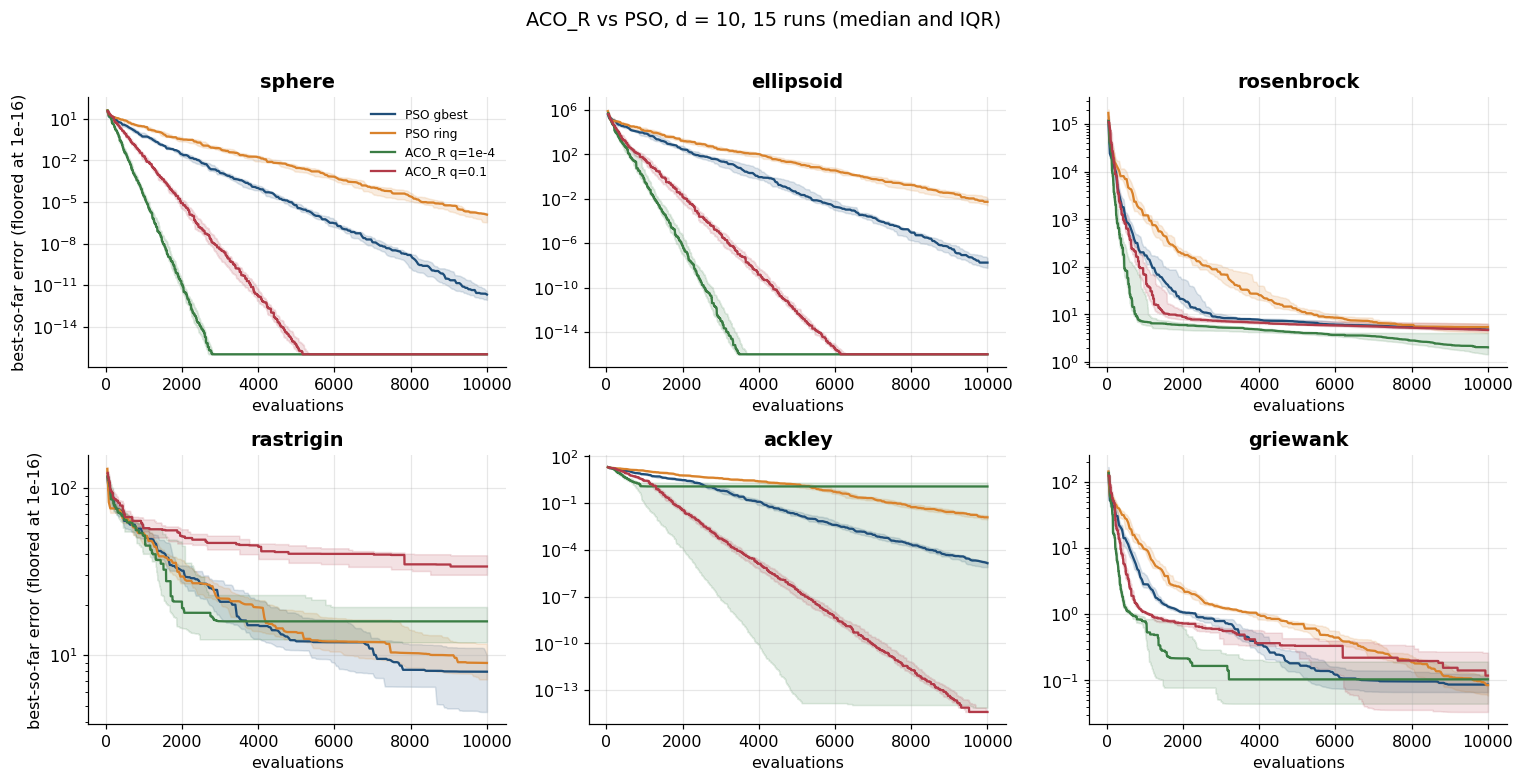

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, fname in zip(axes.ravel(), FN):
    for k, an in enumerate(ALGS):
        r = cmp[fname, an]
        e = np.maximum(r["trace"] - BENCHMARKS[fname].f_opt, 1e-16)
        q1, med, q3 = np.percentile(e, [25, 50, 75], axis=0)
        ax.plot(r["grid"], med, label=an, color=list(PALETTE.values())[k])
        ax.fill_between(r["grid"], q1, q3, alpha=0.15, color=list(PALETTE.values())[k])
    ax.set_yscale("log"); ax.set_title(fname); ax.set_xlabel("evaluations")
axes[0, 0].set_ylabel("best-so-far error (floored at 1e-16)"); axes[1, 0].set_ylabel("best-so-far error (floored at 1e-16)"); axes[0, 0].legend(fontsize=8)
plt.suptitle("ACO_R vs PSO, d = 10, 15 runs (median and IQR)", y=1.01)
plt.tight_layout(); savefig("w5_acor_vs_pso.png"); plt.show()

**Reading the comparison.** With $q=10^{-4}$ ACO$_\mathbb{R}$ always samples around the best archive member with
an archive-spread step size: it behaves like an elitist evolution strategy and is extremely fast on the smooth
unimodal functions (sphere, ellipsoid, and the best median on Rosenbrock), including the ill-conditioned ellipsoid
where its per-coordinate $\sigma^i$ adapts to the different axis scales — a separable-problem advantage it shares with
PSO's coordinate-wise rule. That greediness costs robustness: on Ackley more than half of the $q=10^{-4}$ runs stall in
a local minimum (median error above 1, lower quartile at machine precision), whereas $q=0.1$, which spreads the guides
over the top of the archive, solves Ackley in every run. On Rastrigin both ACO$_\mathbb{R}$ settings are clearly
worse than PSO, and on Griewank the four methods are close. PSO's topology plays the same exploration role as $q$.
Neither family dominates — the "no free lunch" pattern of Week 1 — and the lab repeats this comparison on shifted
*and rotated* functions, where the per-coordinate mechanisms of both methods are put to the test.

*AI relevance.* ACO$_\mathbb{R}$ and CE are both *estimation-of-distribution* optimisers; CE is widely used for
policy search in reinforcement learning (e.g. the CEM planner in model-based RL), and the score-function gradient
of Section 1 is REINFORCE.

## Key takeaways

- ACO is model-based search: pheromones parameterise a distribution over solutions; the evaporation + deposit
  update is a natural-gradient step on expected quality (exact for the independent-decision model), with $\rho$ as
  the learning rate.
- The CE method's smoothed maximum-likelihood update is the same update with the elite as depositing ants; the ML
  step was verified against a numerical optimiser.
- Convergence theory (Gutjahr 2000/2002; Stützle & Dorigo 2002) guarantees convergence in value when sampling
  probabilities stay bounded away from zero ($\tau_{\min}>0$); the bound is useless for runtime, but without
  $\tau_{\min}$ runs can lock in forever, as observed.
- Pheromone entropy quantifies how concentrated the model is: AS concentrates fastest, ACS keeps its pheromone
  nearly uniform (it exploits through $q_0$), MMAS settles exactly at the level set by $p_{\text{best}}$
  (verified to $10^{-6}$).
- ACO$_\mathbb{R}$ turns the pheromone table into a solution archive with rank-based selection and archive-spread
  Gaussian sampling; it is competitive with PSO, with $q$ controlling greediness.

## Exercises

1. ★ Derive the score-function gradient for the TSP construction model $P_\tau(s)=\prod_t p_{s_ts_{t+1}}$ with
   $\theta=\log\tau$ and show that it involves "deposit on used edges minus expected usage".
2. ★ Prove that the CE update with $a=1$ and a single elite sample makes the model deterministic after one
   iteration, and explain why smoothing ($a\lt1$) is essential.
3. ★★ Prove the Stützle–Dorigo bound $P^{\ast}(t)\ge1-(1-\hat p)^t$ and compute $t$ such that the bound exceeds $0.5$
   for the 10-city instance above. Compare with the observed median time to find $s^{\ast}$.
4. ★★ Implement CE for the TSP with a transition-matrix model (rows renormalised after the elite fit) and compare it
   with MMAS at equal tour budgets on 30 cities.
5. ★★ Add the variable-correlation handling of ACO$_\mathbb{R}$ (sampling in a rotated coordinate system built from
   archive differences) and measure its effect on the rotated ellipsoid.
6. ★★★ Implement ACO for the QAP (pheromone $\tau_{ij}$ = "facility $i$ at location $j$", MMAS update) and validate
   it against `qap_brute_force` on $n=8$ over 20 seeds; report the hit rate and mean gap at equal evaluation budgets.